<a href="https://colab.research.google.com/github/amatsukami0420/AI_Lab_Assignments-CSC262/blob/main/AILabMid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Name:** Muhammad Waleed Bin Anwar
## **Registration:** FA24-BCS-110
### **Lab Task:** Artificial Intelligence
### **Teacher:** Zeenat Zulfiqar
### [github](https://github.com/amatsukami0420/AI_Lab_Assignments-CSC262)


# 1.
## Project Overview

In contemporary cybersecurity, threat actors frequently traverse multiple interconnected systems
to reach high-value target assets. Analyzing and understanding the formulation of these "attack
paths" is paramount for engineering secure and resilient networks. This project bridges the
disciplines of Artificial Intelligence and Cybersecurity. Students will model a computer network
as a mathematical graph and apply classical and advanced search algorithms to simulate an
attacker's trajectory toward a target system. Through this exercise, students will implement,
analyze, and compare the efficacy of various search methodologies within a simulated
environment.

# Phase 1: Network Topology Initialization
This section defines the core data structure for the cybersecurity attack simulation. The network is modeled as a directed graph using a native Python dictionary to ensure dynamic loadability.

The graph consists of 10 discrete nodes representing various network entities:
* **`heuristics`**: Represents $h(n)$, estimating the topological distance or vulnerability risk to the target (`DB_Server`). Used by A* and Hill Climbing.
* **`adj_list`**: Contains the edge weights (costs) quantifying the traversal effort required to move between interconnected systems.

In [4]:
# Core graph data structure defined purely in Python
network_graph = {
    "start_node": "Attacker_Entry",
    "goal_node": "DB_Server",

    # Heuristics h(n) for Informed and Local Search
    "heuristics": {
        "Attacker_Entry": 15,
        "Firewall": 12,
        "Web_Server": 10,
        "DMZ_Switch": 8,
        "App_Server": 5,
        "Internal_Router": 6,
        "Auth_Server": 3,
        "Admin_PC": 2,
        "Backup_Server": 4,
        "DB_Server": 0
    },

    # Adjacency List representing connections and traversal costs (weights)
    "adj_list": {
        "Attacker_Entry": {"Firewall": 3, "Web_Server": 8},
        "Firewall": {"Web_Server": 2},
        "Web_Server": {"DMZ_Switch": 2},
        "DMZ_Switch": {"App_Server": 4, "Internal_Router": 3},
        "Internal_Router": {"Auth_Server": 3, "Admin_PC": 5, "Backup_Server": 4},
        "App_Server": {"DB_Server": 6},
        "Auth_Server": {"DB_Server": 4},
        "Admin_PC": {"DB_Server": 1},
        "Backup_Server": {"DB_Server": 5},
        "DB_Server": {} # Target system has no outbound paths
    }
}

print(f"Network Topology Initialized.")
print(f"Entry Point: {network_graph['start_node']} | Target Asset: {network_graph['goal_node']}")

Network Topology Initialized.
Entry Point: Attacker_Entry | Target Asset: DB_Server


In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Fixed coordinates so every exported graph looks identical
node_positions = {
    "Attacker_Entry": (0, 3), "Firewall": (2, 4), "Web_Server": (4, 4),
    "DMZ_Switch": (6, 3), "App_Server": (8, 4), "Internal_Router": (8, 2),
    "Auth_Server": (10, 1), "Admin_PC": (10, 3), "Backup_Server": (10, 5),
    "DB_Server": (12, 3), "Honeypot": (1, 1)
}

def plot_and_save_graph(graph_data, path_taken, title, filename):
    """Draws the graph, highlights the path, and exports a high-res PNG."""
    G = nx.DiGraph()
    for u, neighbors in graph_data["adj_list"].items():
        for v, cost in neighbors.items():
            G.add_edge(u, v, weight=cost)

    # Highlight logic
    node_colors = ['#ff4d4d' if node in path_taken else '#4d79ff' for node in G.nodes()]
    edge_colors = []
    edge_widths = []
    path_edges = list(zip(path_taken, path_taken[1:])) if path_taken else []

    for u, v in G.edges():
        if (u, v) in path_edges:
            edge_colors.append('#ff4d4d') # Red for compromised paths
            edge_widths.append(2.5)
        else:
            edge_colors.append('#cccccc') # Gray for untouched paths
            edge_widths.append(1.0)

    # Plotting
    plt.figure(figsize=(10, 5))
    nx.draw_networkx_nodes(G, node_positions, node_color=node_colors, node_size=1200, edgecolors='black')
    nx.draw_networkx_labels(G, node_positions, font_size=8, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, node_positions, edge_color=edge_colors, width=edge_widths, arrowsize=15)

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, node_positions, edge_labels=labels)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')

    # Save the image for Overleaf
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved visualization to: {filename}")
    plt.show()

# Phase 2: Uninformed Search Algorithms
This section implements Breadth-First Search (BFS) and Depth-First Search (DFS). These algorithms explore the network blindly, without using the heuristic values ($h(n)$).

Per the functional requirements, each algorithm tracks four critical execution metrics:
1. **Discovered Path:** The sequential trajectory of compromised nodes.
2. **Total Cost:** The accumulated edge weights of the traversal.
3. **Nodes Expanded:** The total number of network entities explored.
4. **Execution Time:** The computational time measured in milliseconds.

In [5]:
import time
from collections import deque

def run_bfs(graph):
    """Executes Breadth-First Search (level-by-level exploration)."""
    start_time = time.perf_counter()
    start_node = graph["start_node"]
    goal_node = graph["goal_node"]

    # Queue stores: (current_node, path_taken, accumulated_cost)
    queue = deque([(start_node, [start_node], 0)])
    visited = set()
    nodes_expanded = 0

    while queue:
        current, path, cost = queue.popleft()

        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal_node:
            exec_time = (time.perf_counter() - start_time) * 1000
            return {"Algorithm": "BFS", "Path": path, "Cost": cost, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

        # Explore neighbors
        neighbors = graph["adj_list"].get(current, {})
        for neighbor, edge_cost in neighbors.items():
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor], cost + edge_cost))

    exec_time = (time.perf_counter() - start_time) * 1000
    return {"Algorithm": "BFS", "Path": "Failed", "Cost": 0, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

def run_dfs(graph):
    """Executes Depth-First Search (deep dive exploration)."""
    start_time = time.perf_counter()
    start_node = graph["start_node"]
    goal_node = graph["goal_node"]

    # Stack stores: (current_node, path_taken, accumulated_cost)
    stack = [(start_node, [start_node], 0)]
    visited = set()
    nodes_expanded = 0

    while stack:
        current, path, cost = stack.pop()

        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal_node:
            exec_time = (time.perf_counter() - start_time) * 1000
            return {"Algorithm": "DFS", "Path": path, "Cost": cost, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

        # Reverse neighbors before pushing to stack for standard left-to-right exploration
        neighbors = list(graph["adj_list"].get(current, {}).items())
        for neighbor, edge_cost in reversed(neighbors):
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor], cost + edge_cost))

    exec_time = (time.perf_counter() - start_time) * 1000
    return {"Algorithm": "DFS", "Path": "Failed", "Cost": 0, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

# Test the functions using the network_graph from Cell 1
print("--- BFS Results ---")
print(run_bfs(network_graph))
print("\n--- DFS Results ---")
print(run_dfs(network_graph))

--- BFS Results ---
{'Algorithm': 'BFS', 'Path': ['Attacker_Entry', 'Web_Server', 'DMZ_Switch', 'App_Server', 'DB_Server'], 'Cost': 20, 'Expanded': 7, 'Time (ms)': 0.0418}

--- DFS Results ---
{'Algorithm': 'DFS', 'Path': ['Attacker_Entry', 'Firewall', 'Web_Server', 'DMZ_Switch', 'App_Server', 'DB_Server'], 'Cost': 17, 'Expanded': 6, 'Time (ms)': 0.023}


Saved visualization to: bfs_plot.png


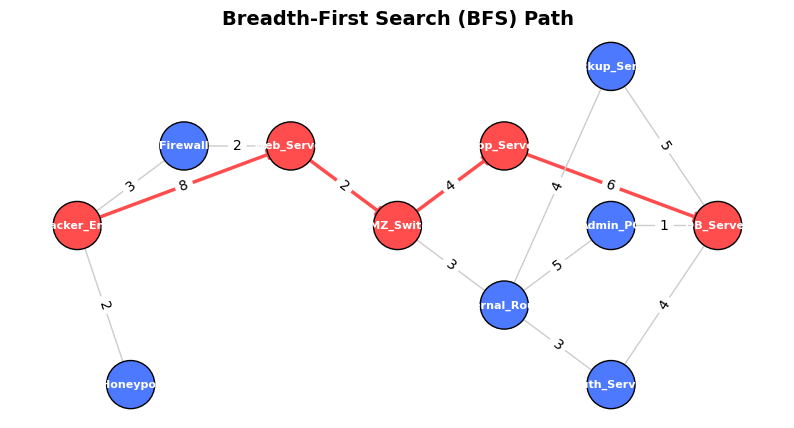

Saved visualization to: dfs_plot.png


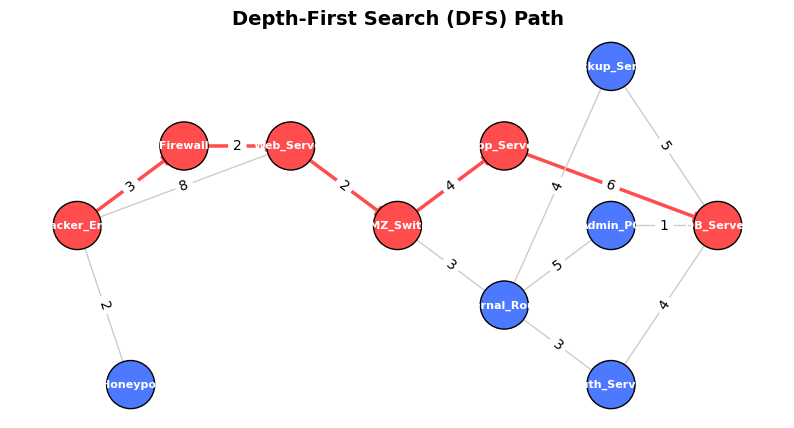

In [10]:
bfs_res = run_bfs(network_graph)
dfs_res = run_dfs(network_graph)

plot_and_save_graph(network_graph, bfs_res["Path"], "Breadth-First Search (BFS) Path", "bfs_plot.png")
plot_and_save_graph(network_graph, dfs_res["Path"], "Depth-First Search (DFS) Path", "dfs_plot.png")

# Phase 3: Informed Search Algorithms
This section implements Uniform Cost Search (UCS) and the A* Search Algorithm.

Unlike uninformed search, these algorithms optimize the path based on cost.
* **UCS:** Explores the path with the lowest accumulated traversal cost ($g(n)$).
* **A*:** Optimizes the search by combining the traversal cost ($g(n)$) with a custom heuristic ($h(n)$). The heuristic estimates the remaining risk or distance to the target system.

In [6]:
import heapq
import time

def run_ucs(graph):
    """Executes Uniform Cost Search (optimizing for lowest edge cost)."""
    start_time = time.perf_counter()
    start_node = graph["start_node"]
    goal_node = graph["goal_node"]

    # Priority Queue stores: (accumulated_cost, current_node, path_taken)
    pq = [(0, start_node, [start_node])]
    visited = set()
    nodes_expanded = 0

    while pq:
        cost, current, path = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal_node:
            exec_time = (time.perf_counter() - start_time) * 1000
            return {"Algorithm": "UCS", "Path": path, "Cost": cost, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

        # Explore neighbors
        neighbors = graph["adj_list"].get(current, {})
        for neighbor, edge_cost in neighbors.items():
            if neighbor not in visited:
                heapq.heappush(pq, (cost + edge_cost, neighbor, path + [neighbor]))

    exec_time = (time.perf_counter() - start_time) * 1000
    return {"Algorithm": "UCS", "Path": "Failed", "Cost": 0, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

def run_astar(graph):
    """Executes A* Search (optimizing for f(n) = g(n) + h(n))."""
    start_time = time.perf_counter()
    start_node = graph["start_node"]
    goal_node = graph["goal_node"]

    # Priority Queue stores: (f_score, accumulated_cost, current_node, path_taken)
    start_h = graph["heuristics"].get(start_node, float('inf'))
    pq = [(0 + start_h, 0, start_node, [start_node])]
    visited = set()
    nodes_expanded = 0

    while pq:
        f_score, cost, current, path = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal_node:
            exec_time = (time.perf_counter() - start_time) * 1000
            return {"Algorithm": "A*", "Path": path, "Cost": cost, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

        # Explore neighbors
        neighbors = graph["adj_list"].get(current, {})
        for neighbor, edge_cost in neighbors.items():
            if neighbor not in visited:
                g_n = cost + edge_cost
                h_n = graph["heuristics"].get(neighbor, float('inf'))
                f_n = g_n + h_n
                heapq.heappush(pq, (f_n, g_n, neighbor, path + [neighbor]))

    exec_time = (time.perf_counter() - start_time) * 1000
    return {"Algorithm": "A*", "Path": "Failed", "Cost": 0, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

# Test the functions
print("--- UCS Results ---")
print(run_ucs(network_graph))
print("\n--- A* Results ---")
print(run_astar(network_graph))

--- UCS Results ---
{'Algorithm': 'UCS', 'Path': ['Attacker_Entry', 'Firewall', 'Web_Server', 'DMZ_Switch', 'Internal_Router', 'Admin_PC', 'DB_Server'], 'Cost': 16, 'Expanded': 10, 'Time (ms)': 0.0427}

--- A* Results ---
{'Algorithm': 'A*', 'Path': ['Attacker_Entry', 'Firewall', 'Web_Server', 'DMZ_Switch', 'Internal_Router', 'Admin_PC', 'DB_Server'], 'Cost': 16, 'Expanded': 9, 'Time (ms)': 0.0337}


Saved visualization to: ucs_plot.png


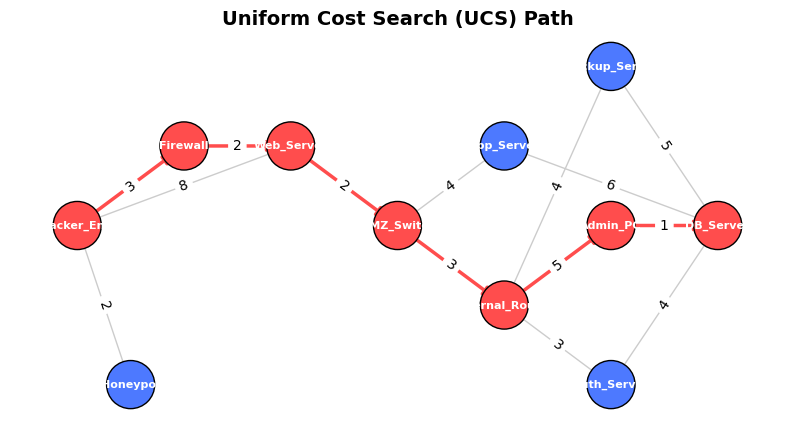

Saved visualization to: astar_plot.png


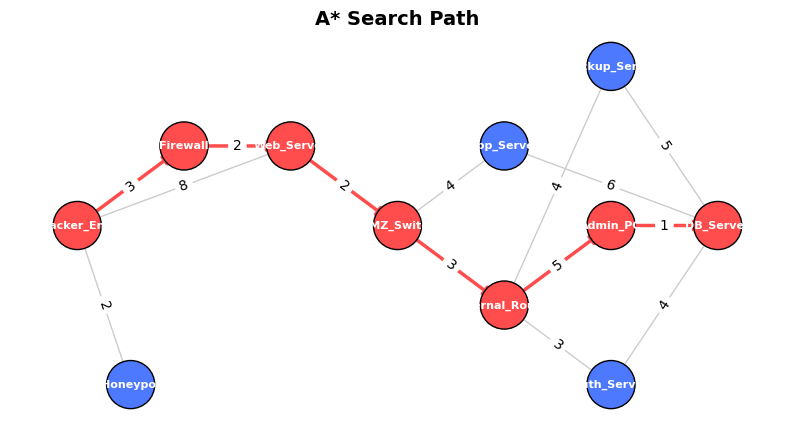

In [11]:
ucs_res = run_ucs(network_graph)
astar_res = run_astar(network_graph)

plot_and_save_graph(network_graph, ucs_res["Path"], "Uniform Cost Search (UCS) Path", "ucs_plot.png")
plot_and_save_graph(network_graph, astar_res["Path"], "A* Search Path", "astar_plot.png")

# Phase 4 & 5: Local and Adversarial Search
This section implements three algorithms:
1. **Hill Climbing (Local Search):** A "Honeypot" node is injected into the graph to demonstrate how this algorithm gets trapped in a local maximum by strictly following the best immediate heuristic.
2. **Minimax (Adversarial Search):** Evaluates a full attack decision tree assuming the attacker maximizes damage and the defender minimizes it.
3. **Alpha-Beta Pruning:** Optimizes the Minimax game tree by pruning branches that will mathematically never be chosen, reducing the number of nodes expanded.

In [16]:
import math
import time

# ==========================================
# 1. Local Search: Hill Climbing
# ==========================================
def run_hill_climbing(graph):
    start_time = time.perf_counter()
    start_node = graph["start_node"]
    goal_node = graph["goal_node"]

    graph["heuristics"]["Honeypot"] = 1
    graph["adj_list"]["Attacker_Entry"]["Honeypot"] = 2
    graph["adj_list"]["Honeypot"] = {}

    current = start_node
    path = [current]
    nodes_expanded = 1
    cost = 0

    while current != goal_node:
        neighbors = graph["adj_list"].get(current, {})
        if not neighbors: break

        best_neighbor = None
        best_h = graph["heuristics"].get(current, float('inf'))
        best_cost = 0

        for neighbor, edge_cost in neighbors.items():
            h_n = graph["heuristics"].get(neighbor, float('inf'))
            if h_n < best_h:
                best_h = h_n
                best_neighbor = neighbor
                best_cost = edge_cost

        if best_neighbor is None: break

        current = best_neighbor
        path.append(current)
        cost += best_cost
        nodes_expanded += 1

    exec_time = (time.perf_counter() - start_time) * 1000
    return {"Algorithm": "Hill Climb", "Path": path, "Cost": cost, "Expanded": nodes_expanded, "Time (ms)": round(exec_time, 4)}

# --- Helper for Adversarial Network Evaluation ---
def evaluate_network_node(graph, node):
    return 15 - graph["heuristics"].get(node, 15)

# ==========================================
# 2. Adversarial Search: Standard Minimax
# ==========================================
def standard_minimax(graph, current, depth, is_attacker, visited, expanded_count):
    expanded_count[0] += 1
    neighbors = [n for n in graph["adj_list"].get(current, {}) if n not in visited]

    # Base case now returns a tuple: (score, [path])
    if depth == 0 or current == graph["goal_node"] or not neighbors:
        return evaluate_network_node(graph, current), [current]

    best_path = []
    if is_attacker:
        best_val = -math.inf
        for n in neighbors:
            visited.add(n)
            val, path = standard_minimax(graph, n, depth - 1, False, visited, expanded_count)
            visited.remove(n)
            if val > best_val:
                best_val = val
                best_path = [current] + path
        return best_val, best_path
    else:
        best_val = math.inf
        for n in neighbors:
            visited.add(n)
            val, path = standard_minimax(graph, n, depth - 1, True, visited, expanded_count)
            visited.remove(n)
            if val < best_val:
                best_val = val
                best_path = [current] + path
        return best_val, best_path

def run_minimax(graph):
    start_time = time.perf_counter()
    expanded = [0]
    optimal_val, optimal_path = standard_minimax(graph, graph["start_node"], 5, True, {graph["start_node"]}, expanded)

    # Calculate path cost manually since it's a dynamic traversal
    cost = sum(graph["adj_list"][optimal_path[i]][optimal_path[i+1]] for i in range(len(optimal_path)-1)) if len(optimal_path) > 1 else 0

    exec_time = (time.perf_counter() - start_time) * 1000
    return {"Algorithm": "Minimax", "Path": optimal_path, "Cost": cost, "Expanded": expanded[0], "Time (ms)": round(exec_time, 4)}

# ==========================================
# 3. Adversarial Search: Alpha-Beta Pruning
# ==========================================
def alpha_beta_logic(graph, current, depth, is_attacker, alpha, beta, visited, expanded_count):
    expanded_count[0] += 1
    neighbors = [n for n in graph["adj_list"].get(current, {}) if n not in visited]

    if depth == 0 or current == graph["goal_node"] or not neighbors:
        return evaluate_network_node(graph, current), [current]

    best_path = []
    if is_attacker:
        best_val = -math.inf
        for n in neighbors:
            visited.add(n)
            val, path = alpha_beta_logic(graph, n, depth - 1, False, alpha, beta, visited, expanded_count)
            visited.remove(n)
            if val > best_val:
                best_val = val
                best_path = [current] + path
            alpha = max(alpha, best_val)
            if beta <= alpha: break
        return best_val, best_path
    else:
        best_val = math.inf
        for n in neighbors:
            visited.add(n)
            val, path = alpha_beta_logic(graph, n, depth - 1, True, alpha, beta, visited, expanded_count)
            visited.remove(n)
            if val < best_val:
                best_val = val
                best_path = [current] + path
            beta = min(beta, best_val)
            if beta <= alpha: break
        return best_val, best_path

def run_alpha_beta(graph):
    start_time = time.perf_counter()
    expanded = [0]
    optimal_val, optimal_path = alpha_beta_logic(graph, graph["start_node"], 5, True, -math.inf, math.inf, {graph["start_node"]}, expanded)

    cost = sum(graph["adj_list"][optimal_path[i]][optimal_path[i+1]] for i in range(len(optimal_path)-1)) if len(optimal_path) > 1 else 0

    exec_time = (time.perf_counter() - start_time) * 1000
    return {"Algorithm": "Alpha-Beta", "Path": optimal_path, "Cost": cost, "Expanded": expanded[0], "Time (ms)": round(exec_time, 4)}

Saved visualization to: hillclimbing_plot.png


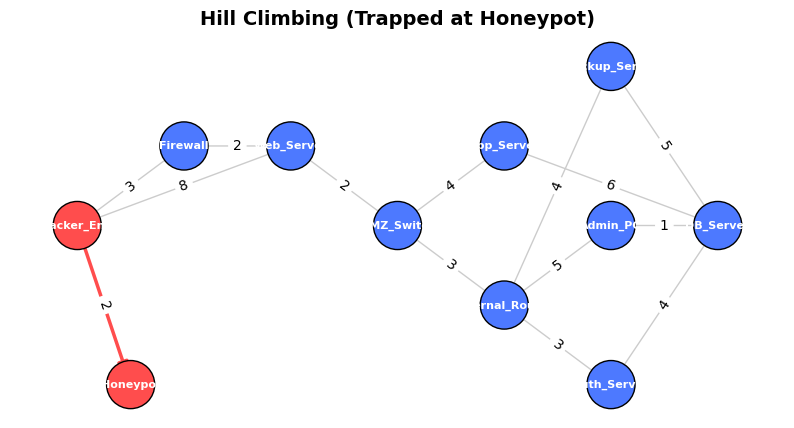

Saved visualization to: minimax_plot.png


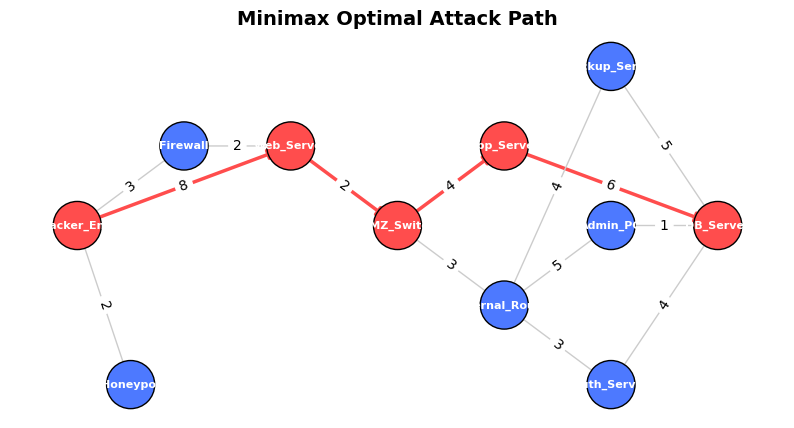

Saved visualization to: alphabeta_plot.png


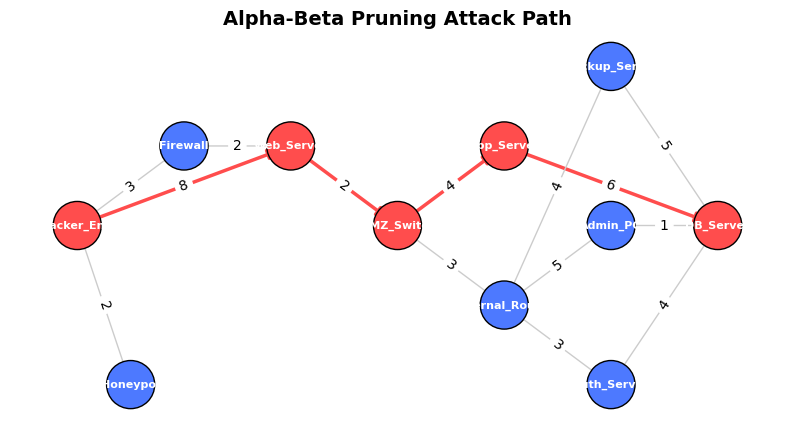

In [17]:
# ==========================================
# Phase 4 & 5: Static Plotting
# ==========================================

# 1. Grab the results from the algorithms
hc_res = run_hill_climbing(network_graph)
mm_res = run_minimax(network_graph)
ab_res = run_alpha_beta(network_graph)

# 2. Plot Hill Climbing
plot_and_save_graph(
    network_graph,
    hc_res["Path"],
    "Hill Climbing (Trapped at Honeypot)",
    "hillclimbing_plot.png"
)

# 3. Plot Minimax
plot_and_save_graph(
    network_graph,
    mm_res["Path"],
    "Minimax Optimal Attack Path",
    "minimax_plot.png"
)

# 4. Plot Alpha-Beta Pruning
plot_and_save_graph(
    network_graph,
    ab_res["Path"],
    "Alpha-Beta Pruning Attack Path",
    "alphabeta_plot.png"
)

# Phase 6: Interactive Network Visualizer (GUI)
This cell generates the Graphical User Interface required by the rubric. It uses `networkx` for plotting the mathematical graph and `ipywidgets` to create an interactive dashboard directly inside Colab.

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Define coordinates for a clean visual layout
node_positions = {
    "Attacker_Entry": (0, 3), "Firewall": (2, 4), "Web_Server": (4, 4),
    "DMZ_Switch": (6, 3), "App_Server": (8, 4), "Internal_Router": (8, 2),
    "Auth_Server": (10, 1), "Admin_PC": (10, 3), "Backup_Server": (10, 5),
    "DB_Server": (12, 3), "Honeypot": (1, 1) # Added honeypot for Hill Climbing
}

# Added Minimax and Alpha-Beta Pruning to the dropdown
algo_dropdown = widgets.Dropdown(
    options=['BFS', 'DFS', 'UCS', 'A*', 'Hill Climbing', 'Minimax', 'Alpha-Beta Pruning'],
    value='A*', description='Algorithm:', layout=widgets.Layout(width='300px')
)
run_button = widgets.Button(description='Simulate Attack', button_style='danger')
metrics_out = widgets.HTML(value="<b>Select an algorithm to visualize the attack path.</b>")
plot_out = widgets.Output()

def draw_visual_graph(path_taken):
    with plot_out:
        clear_output(wait=True)
        G = nx.DiGraph()

        # Build the visual graph from Cell 1's dictionary
        for u, neighbors in network_graph["adj_list"].items():
            for v, cost in neighbors.items():
                G.add_edge(u, v, weight=cost)

        # Colors: Highlight compromised path in red
        node_colors = ['#ff4d4d' if node in path_taken else '#4d79ff' for node in G.nodes()]
        edge_colors = []
        edge_widths = []
        path_edges = list(zip(path_taken, path_taken[1:])) if path_taken else []

        for u, v in G.edges():
            if (u, v) in path_edges:
                edge_colors.append('#ff4d4d')
                edge_widths.append(3)
            else:
                edge_colors.append('#808080')
                edge_widths.append(1)

        plt.figure(figsize=(12, 6), facecolor='#1e1e1e')
        ax = plt.gca()
        ax.set_facecolor('#1e1e1e')

        nx.draw_networkx_nodes(G, node_positions, node_color=node_colors, node_size=1500, edgecolors='white')
        nx.draw_networkx_labels(G, node_positions, font_color='white', font_size=8, font_weight='bold')
        nx.draw_networkx_edges(G, node_positions, edge_color=edge_colors, width=edge_widths, arrowsize=15)

        labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, node_positions, edge_labels=labels, font_color='cyan')

        plt.title("Cybersecurity Attack Path Simulation", color='white', fontsize=14)
        plt.axis('off')
        plt.show()

def on_click(b):
    algo = algo_dropdown.value
    res = {}

    # Execute the selected algorithm
    if algo == 'BFS': res = run_bfs(network_graph)
    elif algo == 'DFS': res = run_dfs(network_graph)
    elif algo == 'UCS': res = run_ucs(network_graph)
    elif algo == 'A*': res = run_astar(network_graph)
    elif algo == 'Hill Climbing': res = run_hill_climbing(network_graph)
    elif algo == 'Minimax': res = run_minimax(network_graph)
    elif algo == 'Alpha-Beta Pruning': res = run_alpha_beta(network_graph)

    draw_visual_graph(res["Path"])

    path_str = " -> ".join(res["Path"]) if isinstance(res["Path"], list) else res["Path"]
    metrics_out.value = f"""
    <div style='background:#2b2b2b; color:#00ff00; padding:10px; border-radius:5px; font-family:monospace;'>
        <b>Algorithm:</b> {res['Algorithm']} <br>
        <b>Path:</b> {path_str} <br>
        <b>Cost:</b> {res['Cost']} | <b>Expanded:</b> {res['Expanded']} | <b>Time:</b> {res['Time (ms)']} ms
    </div>
    """

run_button.on_click(on_click)
display(widgets.VBox([widgets.HBox([algo_dropdown, run_button]), metrics_out, plot_out]))
draw_visual_graph([]) # Draw initial empty state